In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import calendar

import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="Banking_DB",
    user="postgres",
    password="9446" 
)

account_balance = pd.read_sql_query('SELECT account_balance FROM banking_data', conn)

C:\Users\user\AppData\Local\Temp\ipykernel_9304\547428769.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  account_balance = pd.read_sql_query('SELECT account_balance FROM banking_data', conn)


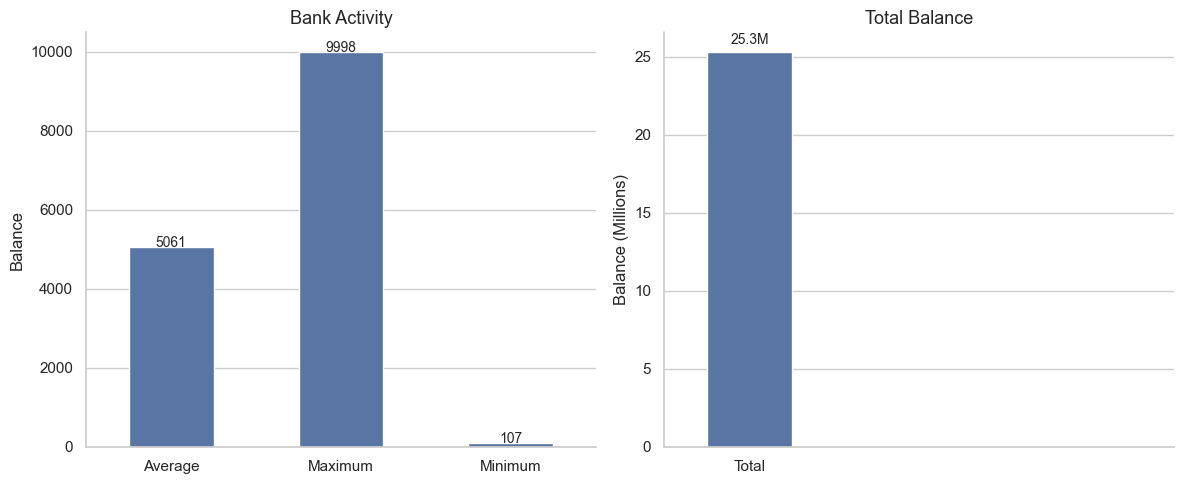

In [5]:
metrics = ['Average', 'Maximum', 'Minimum']
sizes = [5061, 9998, 107]
df = {
  'metrics': ['Average', 'Maximum', 'Minimum'],
  'sizes': [5061, 9998, 107]
}

df_plot = {
    'metric':['Total'],
    'size':[25302854 / 1_000_000]
}

Df = pd.DataFrame(df)
Df_plot = pd.DataFrame(df_plot)

fig, ax=plt.subplots(1, 2, figsize=(12,5))
sns.barplot(Df, x='metrics', y='sizes', width=0.5, ax=ax[0])
sns.set_theme(style='whitegrid')
for i, value in enumerate(Df["sizes"]):
    ax[0].text(i, value + 0.5, f"{value}", ha="center", fontsize=10)
ax[0].set_title('Bank Activity', fontsize=13)
ax[0].set_xlabel("")
ax[0].set_ylabel("Balance")

sns.barplot(Df_plot, x='metric', y='size', width=0.5, ax=ax[1])
for i, value in enumerate(Df_plot["size"]):
    ax[1].text(i, value + 0.5, f"{value:.1f}M", ha="center", fontsize=10)
ax[1].set_title('Total Balance', fontsize=13)
ax[1].set_xlabel("")
ax[1].set_ylabel("Balance (Millions)")
ax[1].set_xlim(ax[0].get_xlim())
sns.despine()
plt.tight_layout()
plt.show()




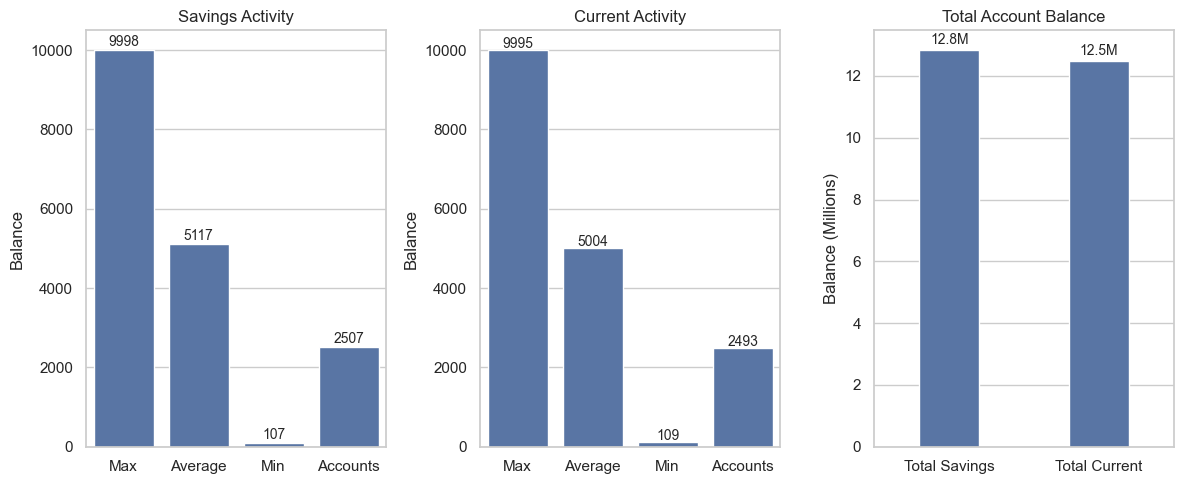

In [4]:
savings = pd.DataFrame({
    'metrics': ["Max", "Average", "Min", "Accounts"],
    "sizes": [9998, 5117, 107, 2507]
})

current = pd.DataFrame({
    "metric": ["Max", "Average", "Min", "Accounts"],
    "size": [9995, 5004, 109, 2493]
})

total =pd.DataFrame({
    "total": ["Total Savings", "Total Current"],
    "balance": [12828982 / 1_000_000, 12473872 / 1_000_000] 
})

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

sns.set_theme(style="whitegrid")
sns.barplot(savings, x="metrics", y="sizes", ax=ax[0])
for i, value in enumerate(savings['sizes']):
    ax[0].text(i, value + 100, f"{value}", ha='center', fontsize=10)
ax[0].set_xlabel("")
ax[0].set_ylabel("Balance")
ax[0].set_title("Savings Activity")

sns.barplot(current, x="metric", y="size", ax=ax[1])
for i, value in enumerate(current['size']):
    ax[1].text(i, value + 50, f"{value}", ha='center', fontsize=10) 
ax[1].set_xlabel("")
ax[1].set_ylabel("Balance")
ax[1].set_title("Current Activity")

sns.barplot(total, x="total", y="balance", width=0.4, ax=ax[2])
for i, value in enumerate(total['balance']):
    ax[2].text(i, value + 0.2, f"{value:.1f}M", ha= 'center', fontsize=10)
ax[2].set_xlabel("")
ax[2].set_ylabel("Balance (Millions)")
ax[2].set_title("Total Account Balance")

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14104\3621448034.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_loans = pd.read_sql_query('''


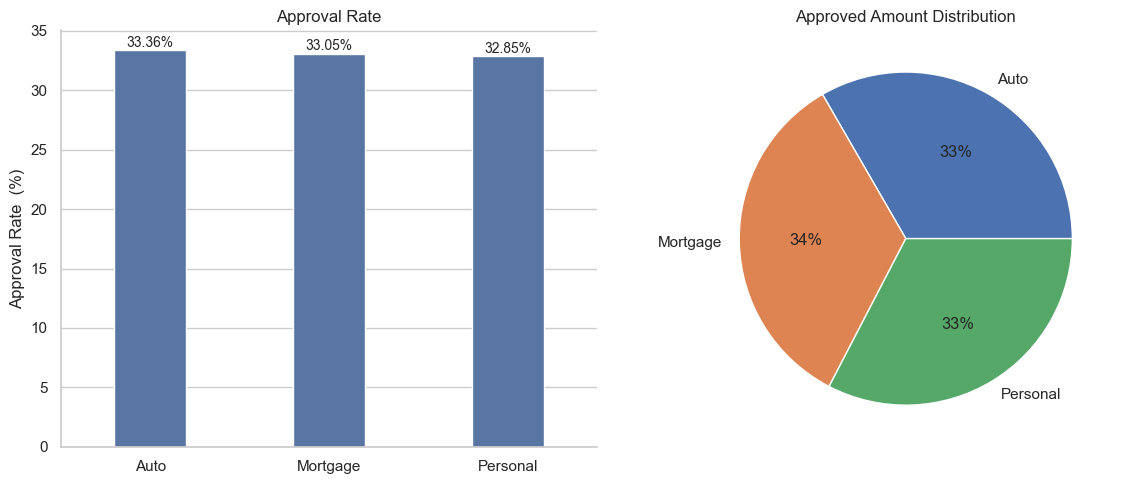

In [4]:
df_loans = pd.read_sql_query('''
SELECT 
    loan_type,
    loan_status,
    COUNT(*) as loan_accounts,
    SUM(
       CASE WHEN loan_status = 'Approved' THEN loan_amount
        ELSE 0
        END
    ) as approved_amount,
    SUM(loan_amount) as total_amount
FROM
    banking_data
GROUP BY
    loan_type,
    loan_status
ORDER BY
    loan_type DESC
''', conn)

approved_df = df_loans[df_loans["loan_status"] == "Approved"].groupby("loan_type")["approved_amount"].sum().reset_index()
total_df = df_loans.groupby("loan_type")["total_amount"].sum().reset_index()
loan_summary = total_df.merge(approved_df, on='loan_type', how='left')
loan_summary['approved_amount'] = loan_summary['approved_amount'].fillna(0)
loan_summary['approval_rate'] = (loan_summary['approved_amount'] / loan_summary['total_amount']) * 100
loan_summary["approved_millions"] = loan_summary["approved_amount"] / 1_000_000

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.set_theme(style="ticks")
colors = sns.color_palette('dark')

sns.barplot(data=loan_summary, x="loan_type", y="approval_rate", ax=ax[0], width=0.4)
for i, value in enumerate(loan_summary["approval_rate"]):
    ax[0].text(i, value + 0.3, f"{value:.2f}%", ha="center", fontsize=10)
ax[0].set_title("Approval Rate")
ax[0].set_ylabel("Approval Rate  (%)")
ax[0].set_xlabel("")

ax[1].pie(loan_summary["approved_amount"], labels=loan_summary["loan_type"], autopct="%.0f%%")
ax[1].set_title("Approved Amount Distribution")

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14104\3190832823.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  approved_loans = pd.read_sql_query('''
C:\Users\user\AppData\Local\Temp\ipykernel_14104\3190832823.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly = approved_loans.groupby('month')['loan_count'].sum().reset_index()


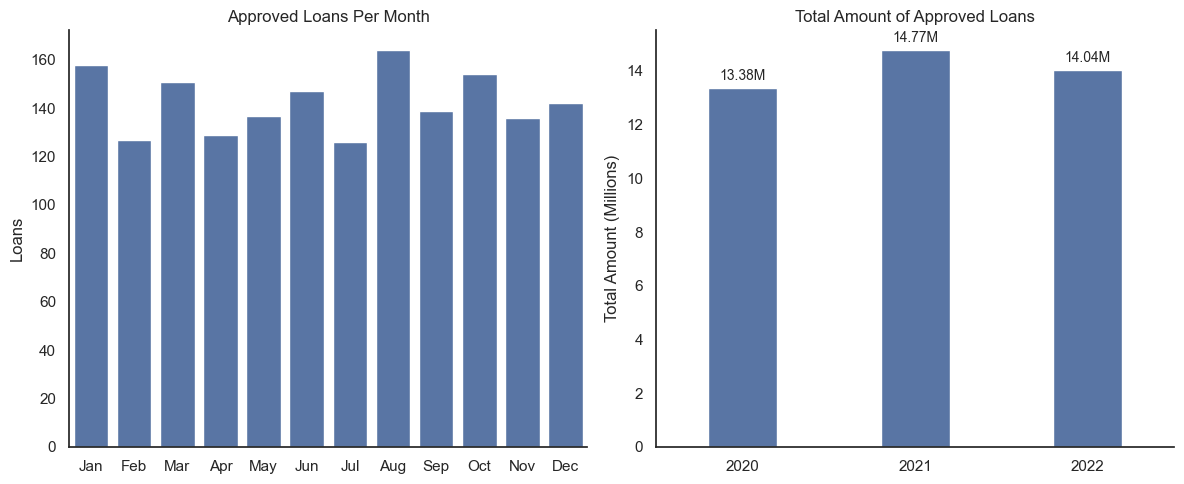

In [18]:
approved_loans = pd.read_sql_query('''
SELECT 
    loan_type,
    SUM(loan_amount) as total_amount,
    COUNT(*) as loan_count,
    EXTRACT(MONTH FROM approval_rejection_date) as Month,
    EXTRACT(YEAR FROM approval_rejection_date) as Year
FROM
    banking_data
WHERE
    loan_status = 'Approved'
GROUP BY
    Month,
    Year,
    loan_type
ORDER BY
    Year DESC,
    Month DESC 
''', conn)

approved_loans["month"] = approved_loans["month"].astype(int)
approved_loans["month"] = approved_loans["month"].apply(lambda x: pd.to_datetime(str(x), format="%m").strftime("%b"))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
approved_loans['month'] = pd.Categorical(approved_loans['month'], categories=month_order, ordered=True)
approved_loans['year'] = approved_loans['year'].astype(int)
monthly = approved_loans.groupby('month')['loan_count'].sum().reset_index()
yearly = approved_loans.groupby('year')['total_amount'].sum().reset_index()
yearly["total_amount"] = yearly['total_amount'] / 1_000_000


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.set_theme(style="white")

sns.barplot(monthly, x='month', y='loan_count', errorbar=None, ax=ax[0])
ax[0].set_xlabel("")
ax[0].set_ylabel("Loans")
ax[0].set_title("Approved Loans Per Month")

sns.barplot(yearly, x="year", y="total_amount", errorbar=None, ax=ax[1], width=0.4)
for i, value in enumerate(yearly['total_amount']):
    ax[1].text(i, value + 0.3, f"{value:.2f}M", ha="center", fontsize=10)
ax[1].set_xlabel("")
ax[1].set_ylabel("Total Amount (Millions)")
ax[1].set_title("Total Amount of Approved Loans")

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_14104\1536782443.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_activity = pd.read_sql_query('''


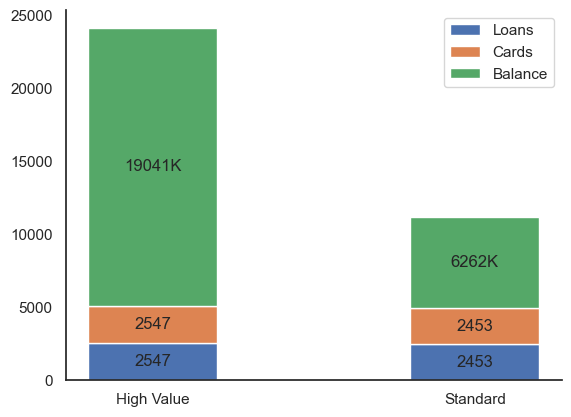

In [44]:
customer_activity = pd.read_sql_query('''
SELECT 
    customer_id,
    SUM(account_balance) as total_balance,
    COUNT(DISTINCT loan_type) as loans,
    COUNT(DISTINCT card_type) as cards,
    CASE WHEN SUM(account_balance) >= 5000 THEN 'High Value'
    ELSE 'Standard'
    END as customer_segment
FROM
    banking_data
GROUP BY
    customer_id
ORDER BY
    total_balance DESC
''', conn)

customer_activity['total_balance'] = customer_activity['total_balance'] / 1_000
grouped = customer_activity.groupby("customer_segment")[["loans", "cards", "total_balance"]].sum().reset_index()
segments = grouped["customer_segment"].tolist()
loans = grouped["loans"].tolist()
cards = grouped["cards"].tolist()
balance = grouped["total_balance"].tolist()

plt.bar(segments, loans, label="Loans", width=0.4)
plt.bar(segments, cards, bottom=loans, label="Cards", width=0.4)
plt.bar(segments, balance, bottom=[loans[i]+cards[i] for i in range(len(loans))], label="Balance", width=0.4)
for i, val in enumerate(loans):
    plt.text(segments[i], val/2, f"{val}", ha="center", va="center") 

for i, val in enumerate(cards):
    plt.text(segments[i], loans[i] + val/2, f"{val}", ha="center", va="center")  

for i, val in enumerate(balance):
    plt.text(segments[i], loans[i]+cards[i] + val/2, f"{val:.0f}K", ha="center", va="center") 
plt.legend()
sns.despine()
plt.show()